In [2]:
from io import BytesIO
from IPython.display import Image as IMG
from keras.preprocessing import image
from shutil import copyfile

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from urllib.request import urlopen
import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import tensorflow as tf
import zipfile, os
import warnings

import time

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import os
warnings.filterwarnings("ignore")

In [3]:
import os
import pandas as pd

# Set working directory to the 'data' folder
folder_path = 'C:/Users/PREDATOR/Downloads/DAMING BARU/data'
os.chdir(folder_path)

# Verify current directory
print("Changed Working Directory to:", os.getcwd())

# List all files in the directory
files = os.listdir()

Changed Working Directory to: C:\Users\PREDATOR\Downloads\DAMING BARU\data


In [4]:
import os

dir_train = os.listdir('C:/Users/PREDATOR/Downloads/DAMING BARU/data/train/')

# cetak jumlah gambar untuk setiap direktori
for path in dir_train:
  print(f'Number of {path} images:' ,len(os.listdir('C:/Users/PREDATOR/Downloads/DAMING BARU/data/train/'+str(path))))

Number of benign images: 1450
Number of malignant images: 1197


In [5]:
dir_test = os.listdir('C:/Users/PREDATOR/Downloads/DAMING BARU/data/test/')

# cetak jumlah gambar untuk setiap direktori.
for path in dir_test:
  print(f'Number of {path} images:' ,len(os.listdir('C:/Users/PREDATOR/Downloads/DAMING BARU/data/test/'+str(path))))

Number of benign images: 360
Number of malignant images: 300


In [6]:


images_data_train = os.path.join('C:/Users/PREDATOR/Downloads/DAMING BARU/data/train/')
list_images_data_train = os.listdir(images_data_train)

images_data_test = os.path.join('C:/Users/PREDATOR/Downloads/DAMING BARU/data/test/')
list_images_data_test = os.listdir(images_data_test)

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

In [8]:
batch_size = 32

data_train = train_datagen.flow_from_directory(
    images_data_train,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
    )

data_val = val_datagen.flow_from_directory(
    images_data_train,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
    )

data_test = val_datagen.flow_from_directory(
    images_data_test,
    # seed=14,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
    )

Found 2647 images belonging to 2 classes.
Found 529 images belonging to 2 classes.
Found 660 images belonging to 2 classes.


In [9]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(data_train.num_classes, activation='softmax')(x)

# Create the model
model_VGG16 = Model(inputs=base_model.input, outputs=predictions)

# # Freeze the layers of ResNet50
# for layer in base_model.layers:
#     layer.trainable = False

In [10]:
# Define callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=10,
    verbose=1
)

checkpoint_path = 'model_checkpoints/weights_MobileNetV2.h5'
checkpoint_dir = os.path.dirname(checkpoint_path)
checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

Epoch 1/50


83/83 [==============================] - 2442s 29s/step - loss: 0.7813 - accuracy: 0.5501 - val_loss: 0.6881 - val_accuracy: 0.5482 - lr: 0.0010
Epoch 2/50
83/83 [==============================] - 6414s 78s/step - loss: 0.6903 - accuracy: 0.5478 - val_loss: 0.6885 - val_accuracy: 0.5482 - lr: 0.0010
Epoch 3/50
83/83 [==============================] - 774s 9s/step - loss: 0.6889 - accuracy: 0.5478 - val_loss: 0.6885 - val_accuracy: 0.5482 - lr: 0.0010
Epoch 4/50
83/83 [==============================] - 607s 7s/step - loss: 0.6889 - accuracy: 0.5478 - val_loss: 0.6886 - val_accuracy: 0.5482 - lr: 0.0010
Epoch 5/50
83/83 [==============================] - 787s 10s/step - loss: 0.6891 - accuracy: 0.5478 - val_loss: 0.6886 - val_accuracy: 0.5482 - lr: 0.0010
Epoch 6/50
83/83 [==============================] - 915s 11s/step - loss: 0.6887 - accuracy: 0.5478 - val_loss: 0.6891 - val_accuracy: 0.5482 - lr: 0.0010
Training time: 11949.68 seconds
17/17 [=============================

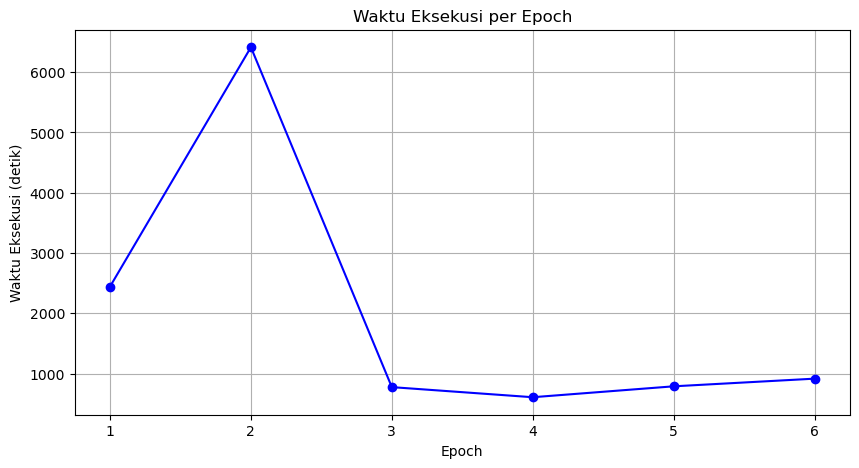

In [11]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback

# Define TimeHistory callback to track epoch execution time
class TimeHistory(Callback):
    def on_train_begin(self, logs={}):
        self.times = []

    def on_epoch_begin(self, epoch, logs={}):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, epoch, logs={}):
        self.times.append(time.time() - self.epoch_time_start)

# Instantiate callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.01)
time_callback = TimeHistory()

# Compile model
model_VGG16.compile(
    optimizer=Adam(learning_rate=0.001),  # Adjusted learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Start timing the training process
start_time = time.time()
# Train model
history = model_VGG16.fit(
    data_train,
    epochs=50,  # Increase the number of epochs
    callbacks=[early_stop, checkpoint, reduce_lr, time_callback],
    verbose=1,
    validation_data=data_val,
)

# End timing the training process
end_time = time.time()

# Calculate the total time taken
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

# Evaluate model
evaluation = model_VGG16.evaluate(data_val)
print(f"Validation loss: {evaluation[0]}")
print(f"Validation accuracy: {evaluation[1]}")
print(f"Training time: {training_time / 60:.2f} minutes")

# Plot grafik waktu eksekusi per epoch
epochs = range(1, len(time_callback.times) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, time_callback.times, marker='o', linestyle='-', color='b')
plt.xlabel('Epoch')
plt.ylabel('Waktu Eksekusi (detik)')
plt.title('Waktu Eksekusi per Epoch')
plt.grid(True)
plt.show()


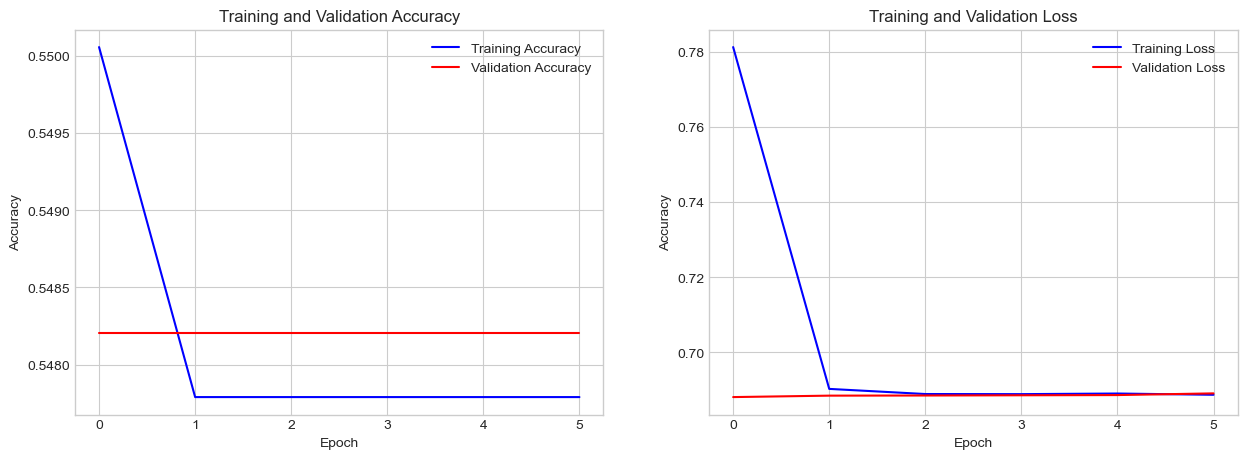

In [12]:
# Plotting hasil training

plt.style.use('seaborn-whitegrid')

def plot_acc(history):
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']
  epochs = range(len(acc))
  plt.subplot(1, 2, 1)
  acc_plot, = plt.plot(epochs, acc, 'b')
  val_acc_plot, = plt.plot(epochs, val_acc, 'r')
  plt.title('Training and Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend([acc_plot, val_acc_plot], ['Training Accuracy', 'Validation Accuracy'])


def plot_loss(history):
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  epochs = range(len(loss))
  plt.subplot(1, 2, 2)
  loss_plot, = plt.plot(epochs, loss, 'b')
  val_loss_plot, = plt.plot(epochs, val_loss, 'r')
  plt.title('Training and Validation Loss')
  plt.legend([loss_plot, val_loss_plot], ['Training Loss', 'Validation Loss'])

def plot_history(history):
  plt.figure(figsize=(15,5))
  plot_acc(history)
  plot_loss(history)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')

plot_history(history)

In [15]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

train_VGG16_result = model_VGG16.evaluate(data_train)
val_VGG16_result = model_VGG16.evaluate(data_val)
test_VGG16_result = model_VGG16.evaluate(data_test)

model_VGG16_result = pd.DataFrame(zip(train_VGG16_result, val_VGG16_result, test_VGG16_result),
                             columns=['Train', 'Validation', 'Testing'],
                             index=['Loss', "Accuracy"])

model_VGG16_result

21/21 [==============================] - 81s 4s/step - loss: 0.6881 - accuracy: 0.5455


,Train,Validation,Testing
Loss,0.687689,0.688081,0.688124
Accuracy,0.547790,0.548204,0.545455


In [16]:
def predict_image(image_upload, model = model_VGG16):
  im = image_upload
  im_array = np.asarray(im)
  im_array = im_array*(1/225)
  im_input = tf.reshape(im_array, shape = [1, 224, 224, 3])

  predict_array = model.predict(im_input)[0]

  import pandas as pd
  df = pd.DataFrame(predict_array)
  df = df.rename({0:'Probability'}, axis = 'columns')
  prod = ['benign', 'malignant']
  df['Images'] = prod
  df = df[['Images', 'Probability']]

  predict_label = np.argmax(model.predict(im_input))

  if predict_label == 0:
    predict_product = 'benign'
  else:
    predict_product = 'malignant'

  return predict_product, df

21/21 [==============================] - 36s 2s/step
              precision    recall  f1-score   support

      benign       0.55      1.00      0.71       360
   malignant       0.00      0.00      0.00       300

    accuracy                           0.55       660
   macro avg       0.27      0.50      0.35       660
weighted avg       0.30      0.55      0.39       660



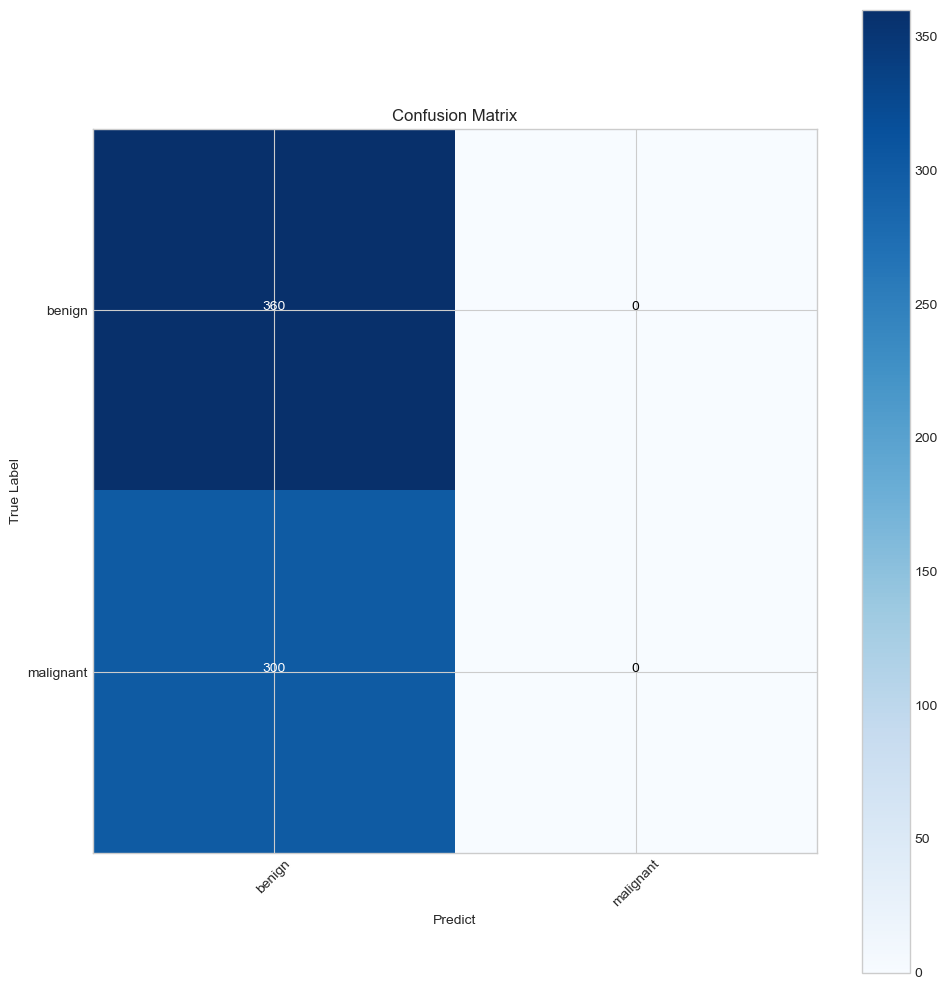

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report

# Predict the labels for the test data
preds = model_VGG16.predict(data_test)

# Convert predictions to label indices
y_pred = np.argmax(preds, axis=1)

# True labels
y_true = data_test.classes

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Get class names
g_dict = data_test.class_indices
classes = list(g_dict.keys())

# Plot confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predict')

# Generate classification report
report = classification_report(y_true, y_pred, target_names=classes)
print(report)

# # Define the file path where to save the report
# file_path = "/content/drive/MyDrive/"

# # Save the classification report to a file
# with open(file_path, "w") as file:
#     file.write(report)
